## Урок 9. Active Learning

В этом уроке мы будем учить модель для классификации, постепенно доразмечая данные для нее разными техниками.

### План

1. Загрузка данных и выбор модели
2. Uncertainry sampling
3. Diversity sampling
4. Семплирование с учетом цены

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Загрузка данных

В качестве данных возьмем академический датасет: [20 Newsgroups](https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html). Этот датасет уже около 30 лет используется для тестирования моделей на задаче классификации. Он содержит 19 тысяч записей из 20 новостных групп, которые разделены на 11.5 тысяч тренировочных текстов и 7.5 тысяч тестовых.

In [ ]:
from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset='train')
newsgroups_test = fetch_20newsgroups(subset='test')

In [ ]:
len(newsgroups_train.data), len(newsgroups_test.data)

(11314, 7532)

In [ ]:
print(newsgroups_train.data[0])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [ ]:
newsgroups_train.target_names, len(newsgroups_train.target_names)

(['alt.atheism',
  'comp.graphics',
  'comp.os.ms-windows.misc',
  'comp.sys.ibm.pc.hardware',
  'comp.sys.mac.hardware',
  'comp.windows.x',
  'misc.forsale',
  'rec.autos',
  'rec.motorcycles',
  'rec.sport.baseball',
  'rec.sport.hockey',
  'sci.crypt',
  'sci.electronics',
  'sci.med',
  'sci.space',
  'soc.religion.christian',
  'talk.politics.guns',
  'talk.politics.mideast',
  'talk.politics.misc',
  'talk.religion.misc'],
 20)

Классы в этом датасете достаточно хорошо сбалансированы.

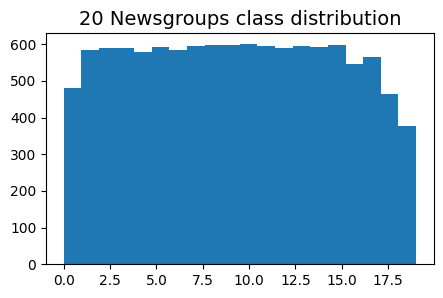

In [ ]:
plt.figure(figsize=(5, 3))
plt.hist(newsgroups_train.target, bins=20);
plt.title('20 Newsgroups class distribution', size=14)
plt.show()

Стандартно для оценки качества на этом датасете используется F1 мера.

In [ ]:
from sklearn.metrics import f1_score

## Модель классификации

Мы будем использовать очень простую модель – Наивный байес поверх TF-IDF признаков. Нам придется обучать ее очень много раз, поэтому ничего сложного брать не хочется. Для демонстрации активного обучения такая комбинация отлично подойдет.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [ ]:
tfidf = TfidfVectorizer(min_df=3)

train_tfidf = tfidf.fit_transform(newsgroups_train.data)
test_tfidf = tfidf.transform(newsgroups_test.data)

In [ ]:
len(tfidf.vocabulary_)

38869

In [ ]:
unlabeled_data = np.array(list(zip(train_tfidf, newsgroups_train.target)))

## Active learning

<img src="https://i.ibb.co/HTwm9tm/al-pipeline.png" alt="drawing" width="600"/>



Сперва напишем код для общего цикла активного обучения. Далее мы будем переписывать в нем функцию `get_scores` для каждой техники выбора текстов для разметки.

In [ ]:
from scipy.sparse import vstack


class ActiveLearning:
    def __init__(self, unlabeled_data, min_training_items=512, label_num=128):
        self.unlabeled_data = np.array(unlabeled_data)
        self.labeled_data = []

        # модель, которую мы будем обучать
        self.model = MultinomialNB(alpha=0.01)
        # число стартовых размеченных текстов
        self.min_training_items = min_training_items
        # число текстов для разметки на каждом шаге
        self.label_num = label_num

    def init_labeled_data(self):
        """
        Выбираем случайные стартовые тексты для разметки
        """
        np.random.seed(0)
        idxs = np.random.choice(
            np.arange(len(self.unlabeled_data)),
            size=self.min_training_items,
            replace=False
        )

        self.labeled_data = self.unlabeled_data[idxs]
        self.unlabeled_data = np.delete(self.unlabeled_data, idxs, 0)

    def get_probs(self):
        """
        Возвращает предсказания вероятностей для всех неразмеченных текстов
        """
        x = self.unlabeled_data[:, 0]
        x = vstack(x)
        probs = self.model.predict_proba(x)
        return probs

    def get_scores(self):
        """
        Возвращает оценки для всех неразмеченных текстов.
        На основе этих оценок происходит выбор текстов для разметки.
        """
        if len(self.unlabeled_data) <= self.label_num:
            return np.zeros(len(self.unlabeled_data))

        return np.random.rand(len(self.unlabeled_data))

    def label_additional_data(self):
        """
        Размечает порцию текстов в соответствии с их оценками
        """
        if len(self.labeled_data) == 0:
            self.init_labeled_data()
            return

        scores = self.get_scores()
        idxs = np.argsort(scores)[-self.label_num:]

        self.labeled_data = np.concatenate((self.labeled_data, self.unlabeled_data[idxs]))
        self.unlabeled_data = np.delete(self.unlabeled_data, idxs, 0)

    def train_model(self):
        """
        Обучает модель на всех размеченных текстах
        """
        assert len(self.labeled_data) > 0, "You don't have any labeled data"

        x = self.labeled_data[:, 0]
        x = vstack(x)
        y = self.labeled_data[:, 1].astype(int)
        self.model.fit(x, y)

In [ ]:
def run_active_learning(unlabeled_data, al_classes, names):
    """
    Запускает процесс активного обучения для всех классов `al_classes`
    и сохраняет траектории F1 меры в процессе доразметки
    """
    results = dict()

    for al_class, name in zip(al_classes, names):
        al = al_class(unlabeled_data)

        f1s = []
        while len(al.unlabeled_data) > 0:
            al.label_additional_data()
            al.train_model()

            test_pred = al.model.predict(test_tfidf)
            f1 = f1_score(newsgroups_test.target, test_pred, average='macro')
            f1s.append(f1)

        results[name] = f1s

    return results

In [ ]:
def plot_results(results):
    """
    Отрисовывает траектории, полученные из `run_active_learning`
    """

    plt.figure(figsize=(5, 3))
    for name, f1s in results.items():
        plt.plot(f1s, label=name)

    plt.xlabel('AL step', size=12)
    plt.ylabel('F1 score', size=12)
    plt.legend()
    plt.grid()
    plt.show()

Посмотрим на то, как изменяется качество модели при доразметке случайных текстов.

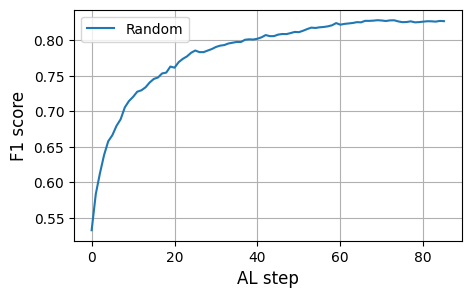

In [ ]:
results = run_active_learning(unlabeled_data, [ActiveLearning], names=['Random'])
plot_results(results)

## Uncertainty sampling

Начнем с рассмотрения техник Uncertainry sampling. Мы будем доразмечать тексты, в предсказании которых модель наименее уверена.


<img src="https://i.ibb.co/YbT2d4w/Group-48099639.png" alt="drawing" width="300"/>

### Least Confident

Размечаем те тексты, для которых вероятность самого вероятного класса мала.

$$score(x) = 1 - \mathbb{P}(\hat{y} | x)$$

<img src="https://i.ibb.co/wMQYg26/least-conf.png" alt="drawing" width="200"/>

In [ ]:
class LeastConfidentAL(ActiveLearning):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def get_scores(self):
        probs = self.get_probs()

        least_conf_score = 1 - probs.max(axis=1)
        return least_conf_score

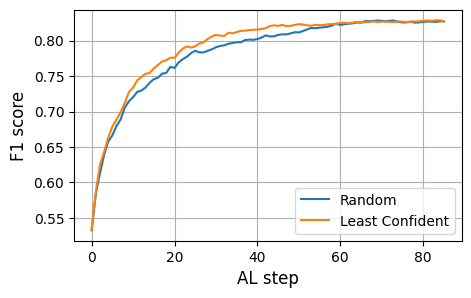

In [ ]:
results.update(run_active_learning(unlabeled_data, [LeastConfidentAL], names=['Least Confident']))
plot_results(results)

Видно, что качество такого подхода обгоняет случайное семплирование. Значит активное обучение работает, ура!

### Margin of Confidence

У Least Confident есть важный недостаток – он не учитывает вероятности остальных классов. Попробуем размечать тексты, для который разница вероятностей между наиболее вероятными классами минимальна.

$$score(x) = 1 - (\mathbb{P}(\hat{y}_1 | x) - \mathbb{P}(\hat{y}_2 | x))$$

<img src="https://i.ibb.co/FKqSqQQ/margin-conf.png" alt="drawing" width="200"/>

In [ ]:
class MarginConfidenceAL(ActiveLearning):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def get_scores(self):
        probs = self.get_probs()

        top_2_probs = np.partition(probs, -2, axis=1)[:, -2:]
        margin_score = 1 - np.abs(top_2_probs[:, 0] - top_2_probs[:, 1])

        return margin_score

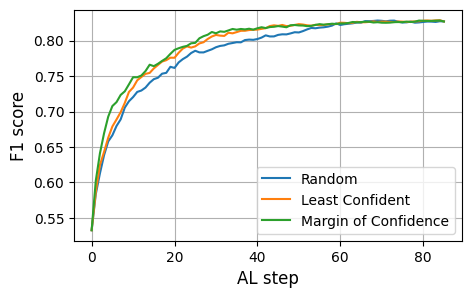

In [ ]:
results.update(run_active_learning(unlabeled_data, [MarginConfidenceAL], names=['Margin of Confidence']))
plot_results(results)

На начальных итерациях качество такого подхода оказывается еще выше!

### Ratio of Confidence

Иногда лучше работает отношение вероятностей вместо разности.

$$score(x) = \frac{\mathbb{P}(\hat{y}_2 | x)}{\mathbb{P}(\hat{y}_1 | x)}$$

In [ ]:
class RatioConfidenceAL(ActiveLearning):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def get_scores(self):
        probs = self.get_probs()

        top_2_probs = np.partition(probs, -2, axis=1)[:, -2:]
        ratio_score = np.min(top_2_probs, axis=-1) / np.max(top_2_probs, axis=-1)
        return ratio_score

In [ ]:
del results['Least Confident']

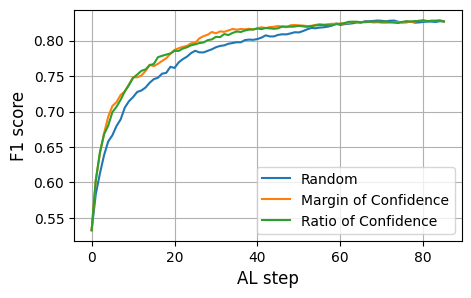

In [ ]:
results.update(run_active_learning(unlabeled_data, [RatioConfidenceAL], names=['Ratio of Confidence']))
plot_results(results)

В нашем случае разницы между ними нет.

### Label Entropy

До этого мы учитывали только две наибольшие вероятности. Можно попробовать рассмотреть все.

$$score(x) = - \sum_{k=1}^K \mathbb{P}(y_k | x) \log \mathbb{P}(y_k | x)$$

In [ ]:
class EntropyAL(ActiveLearning):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def get_scores(self):
        probs = self.get_probs()

        entropy = -np.sum(probs * np.log(probs), axis=-1)
        return entropy

In [ ]:
del results['Ratio of Confidence']

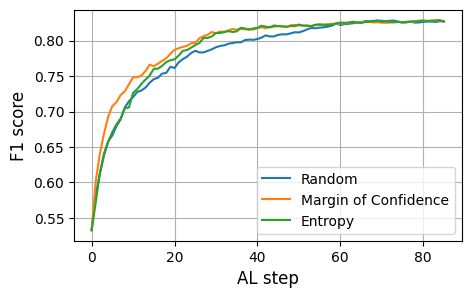

In [ ]:
results.update(run_active_learning(unlabeled_data, [EntropyAL], names=['Entropy']))
plot_results(results)

Энтропия показывает себя хуже всего, потому что семлирует очень похожие тексты из центра распределения.

<img src="https://i.ibb.co/yN2JX7f/Group-48099647.png" alt="drawing" width="800"/>

## Diversity sampling

Перейдем ко второй группе методов, направленных на разметку наиболее разнообразных текстов.

<img src="https://i.ibb.co/fdt3MWf/diversity-sampling.png" alt="drawing" width="300"/>

### Cluster-based

Подход на основе кластеров размечает тексты из всех кластеров равномерно. При этом в из каждого кластера мы берем несколько случайных текстов, центральный текст и выброс.

<img src="https://i.ibb.co/nCjnkTx/cluster.png" alt="drawing" width="400"/>

In [ ]:
from sklearn.metrics import pairwise_distances_argmin, pairwise_distances
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer


class ClusterBasedAL(ActiveLearning):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.label_num_ = self.label_num

    def get_scores(self):
        self.label_num = self.label_num_

        if len(self.unlabeled_data) <= self.label_num:
            return np.zeros(len(self.unlabeled_data))

        x = self.unlabeled_data[:, 0]
        x = vstack(x)

        lsa = make_pipeline(TruncatedSVD(n_components=100), Normalizer(copy=False))
        x_lsa = lsa.fit_transform(x)

        kmeans = KMeans(n_clusters=self.label_num // 5).fit(x_lsa)
        closest_idxs = list(pairwise_distances_argmin(kmeans.cluster_centers_, x_lsa))

        outlier_idxs = []
        for cluster_idx in range(kmeans.n_clusters):
            cluster_x = x_lsa[kmeans.labels_ == cluster_idx]
            centroid = kmeans.cluster_centers_[cluster_idx]
            dists = pairwise_distances([centroid], cluster_x)[0]
            idx = np.argmax(dists[0])
            outlier_idxs.append(np.where(kmeans.labels_ == cluster_idx)[0][idx])

        random_cluster_idxs = []
        for cluster_idx in range(kmeans.n_clusters):
            idxs = np.random.choice(
                np.where(kmeans.labels_ == cluster_idx)[0],
                size=3,
            )
            random_cluster_idxs.extend(idxs)

        idxs = np.unique(closest_idxs + outlier_idxs + random_cluster_idxs)
        self.label_num = len(idxs)

        scores = np.zeros(len(self.unlabeled_data))
        scores[idxs] = 1
        return scores

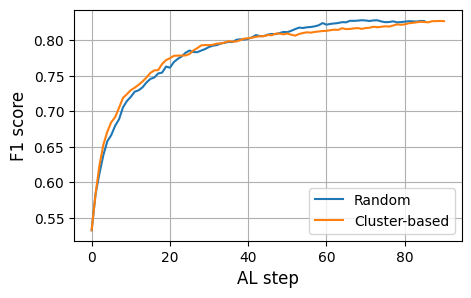

In [ ]:
results = run_active_learning(unlabeled_data, [ActiveLearning, ClusterBasedAL], names=['Random', 'Cluster-based'])
plot_results(results)

Видим, что относительно случайного семплирования такая техника немного улучшила качество вначале, но ухудшила в конце. Дело в том, что, когда данных достаточно много, важнее размечать наиболее сложные тексты, а не разнообразные.

## Учитываем стоимость

На практике очень часто бывает полезно учитывать стоимость разметки текстов при выборе данных, так как бюджет часто ограничен. Логично отдавать предпочтение дешевым текстам.

Мы опробуем две техники:
1. Отказ от текстов, если их стоимость больше определенного порога
2. Return on Investment (ROI)

Сперва введем функцию стоимости и перепишем функции, чтобы они поддерживали логирование стоимостей. Стоимость будет считаться как число слов в тексте.

In [ ]:
def get_text_prices(texts):
    return np.array([len(text.split()) for text in texts])

Добавим цены в наши данные.

In [ ]:
prices = get_text_prices(newsgroups_train.data)

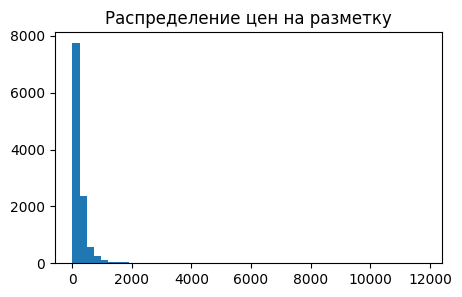

In [ ]:
plt.figure(figsize=(5, 3))
plt.title('Распределение цен на разметку')
plt.hist(prices, bins=50);

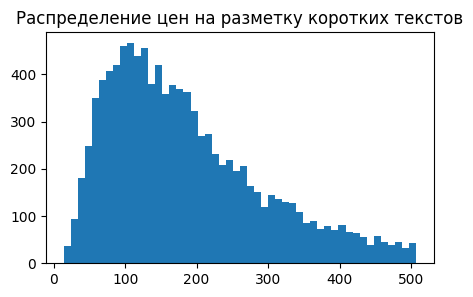

In [ ]:
plt.figure(figsize=(5, 3))
long_quantile = np.quantile(prices, 0.9)
plt.title('Распределение цен на разметку коротких текстов')
plt.hist(prices[prices < long_quantile], bins=50);

In [ ]:
prices = (prices - prices.min() + 1e-6) / (prices.max() - prices.min())
unlabeled_data = np.array(list(zip(train_tfidf, newsgroups_train.target, prices)))

In [ ]:
def run_price_active_learning(unlabeled_data, al_classes, names):
    results = dict()

    for al_class, name in zip(al_classes, names):
        al = al_class(unlabeled_data)

        f1s = []
        prices = []
        while len(al.unlabeled_data) > 0:
            al.label_additional_data()
            al.train_model()

            test_pred = al.model.predict(test_tfidf)
            f1 = f1_score(newsgroups_test.target, test_pred, average='macro')
            f1s.append(f1)

            prices.append(al.labeled_data[:, 2].sum())

        results[name] = {'f1': f1s, 'price': prices}

    return results

In [ ]:
def plot_price_results(results):
    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    for name, data in results.items():
        plt.plot(data['f1'], label=name)

    plt.xlabel('AL step', size=12)
    plt.ylabel('F1 score', size=12)
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    for name, data in results.items():
        plt.plot(data['price'], label=name)

    plt.xlabel('AL step', size=12)
    plt.ylabel('Label price', size=12)
    plt.legend()
    plt.grid()

    plt.show()

### Не берем дорогие тексты

Введем ограничение на тексты по цене и не будем размечать тексты, состоящие из больше чем примерно 500 слов. Напишем немного костыльную обертку, которая учитывает этот критерий при отборе текстов.

In [ ]:
threshold = np.quantile(prices, 0.9)

In [ ]:
class MaxPriceActiveLearning:
    def __init__(self, al_class, *args, price_threshold=threshold, **kwargs):
        self.al_class = al_class(*args, **kwargs)
        self.get_orig_scores = self.al_class.get_scores
        self.al_class.get_scores = self.get_scores
        self.price_threshold = price_threshold

        assert self.al_class.unlabeled_data.shape[1] == 3, 'There is no texts in data'

    def get_scores(self):
        scores = self.get_orig_scores()
        prices = self.al_class.unlabeled_data[:, 2]

        scores[prices > self.price_threshold] = -1e+6

        return scores

    def __getattr__(self, name):
        return getattr(self.al_class, name)

In [ ]:
from functools import partial

In [ ]:
results = run_price_active_learning(
    unlabeled_data,
    [ActiveLearning, partial(MaxPriceActiveLearning, ActiveLearning), partial(MaxPriceActiveLearning, MarginConfidenceAL)],
    names=['Random', 'Price + Random', 'Price + Margin']
)

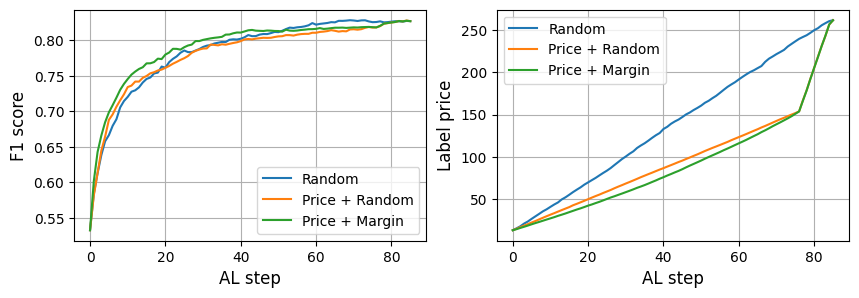

In [ ]:
plot_price_results(results)

Нам удалось почти не потерять в качестве и сильно сэкономить по деньгам на разметке.

## Return on Investment

Более умная техника – вводить штраф, пропорциональный стоимости. Для этого можно использовать Return on Investment, который будет показывать, насколько много мы получим за единицу стоимости.

$$
ROI(x) = \frac{uncertainty(x)}{cost(x)}
$$

Может быть полезно масштабировать стоимость и неуверенность, чтобы минимум был в 0.

In [ ]:
class ROIActiveLearning:
    def __init__(self, al_class, *args, **kwargs):
        self.al_class = al_class(*args, **kwargs)
        self.get_orig_scores = self.al_class.get_scores
        self.al_class.get_scores = self.get_scores

        assert self.al_class.unlabeled_data.shape[1] == 3, 'There is no texts in data'

    def get_scores(self):
        scores = self.get_orig_scores()
        prices = self.al_class.unlabeled_data[:, 2]

        return scores / prices

    def __getattr__(self, name):
        return getattr(self.al_class, name)

In [ ]:
results = run_price_active_learning(
    unlabeled_data,
    [ActiveLearning, partial(ROIActiveLearning, ActiveLearning), partial(ROIActiveLearning, MarginConfidenceAL)],
    names=['Random', 'ROI + Random', 'ROI + Margin']
)

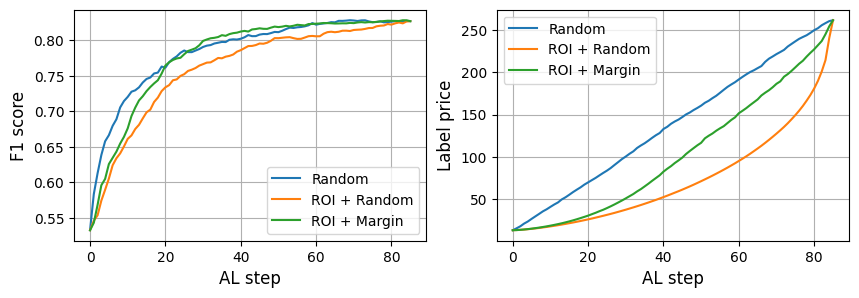

In [ ]:
plot_price_results(results)

Сравним теперь оба подхода.

In [ ]:
results = run_price_active_learning(
    unlabeled_data,
    [ActiveLearning, partial(MaxPriceActiveLearning, MarginConfidenceAL), partial(ROIActiveLearning, MarginConfidenceAL)],
    names=['Random', 'Price + Margin', 'ROI + Margin']
)

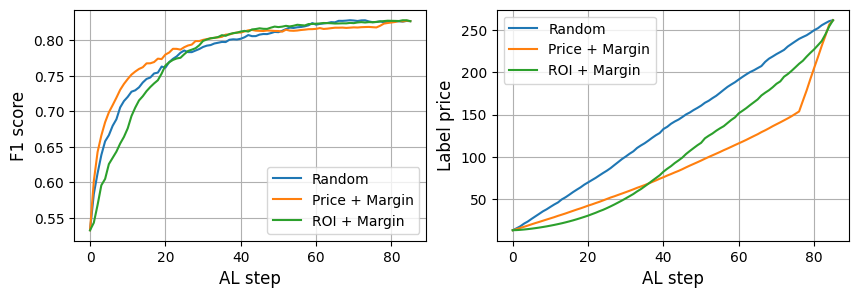

In [ ]:
plot_price_results(results)

Внезапно получаем, что более простой способ приводит к лучшему качеству. Так произошло из-за того, что распределение стоимостей очень неравномерно. Есть небольшой набор слишком дорогих текстов, не размечая которые мы экономим кучу денег.

### Резюме

1. Мы убедились, что с помощью Active Learning можно улучшить качество модели в условиях ограниченного бюджета на разметку.
1. Увидели, что различные методы Uncertainty Sampling дают разный результат. Иногда он зависит от самих данных, но чаще всего используется Margin of Confidence.
1. Адаптировали наши методы под учет стоимости разметки и смогли потратить еще меньше денег.

### Практические советы

__Мониторинг__

В реальном мире возможности тестировать разные стратегии выбора признаков нет. Приходится модифицировать стратегию по ходу обучения и тщательно следить за процессом. Вот несколько пунктов, которые надо держать в голове при реализации Active Learning:

1. Отслеживайте изменения во всех метриках модели. Если модель не улучшается, то возможно
    1. Вы размечаете слишком мало новых данных по сравнению с текущим размером датасета.
    1. Стратегия отбора данных уже неоптимальна и ее надо сменить.
    1. У вас баг в коде из-за которого вы размечаете не те данные
    1. Датасет уже слишком большой и никакие новые данные не помогут.
1. На каждой итерации score для размеченных данных должен уменьшаться. Если нет, то вы семплируете похожие примеры. Если вы используете Uncertainty Sampling, то неуверенность может исходить из самих данных, а не модели.

__Эффективность__

Цикл обучения модели, выбора данных для разметки, отправки выбранных данных и их разметки может быть очень долгим. Из-за этого обучение всей модели замедлится. Чтобы его ускорить важно помнить о следующем:

1. Старайтесь автоматизировать все, что можно. В Active Learning нельзя автоматизировать только саму ручную разметку.
1. Не все сервисы позволяют догружать данные для разметки. Убедитесь в том, что ваш сервис позволяет это делать быстро и что разметчики не ждут, когда доедут новые данные.
1. Размер батча для разметки должен быть достаточно большим, чтобы повлиять на модель. Если он слишком маленький, то вы просто потратите время на циклы закрузки и выгрузки новых данных.


### Полезные фреймворки для Active Learning

1. [`modAL`](https://modal-python.readthedocs.io/en/latest/) – фреймворк на Python3 для постоения систем активного обучения. В нем реализованы все основные техники Active Learning. Вот так можно настроить пайплайн обучения:

```
from modAL.models import ActiveLearner
from sklearn.ensemble import RandomForestClassifier

# инициализация главного класса
learner = ActiveLearner(
    estimator=RandomForestClassifier(),
    X_training=X_training, y_training=y_training
)

# X_pool содержит все неразмеченные данные
query_idx, query_inst = learner.query(X_pool)

# query_idx – индексы для данных разметки
# y_new – невые размеченные данные
learner.teach(X_pool[query_idx], y_new)
```

2. [`libact`](https://libact.readthedocs.io/en/latest/) – фреймвок с похожим функционалом, который также позволяет на ходу выбирать оптимальную стратегию для выбора данных. Его интерфейс выглядит вот так:

```
# Датасет с размеченными и неразмеченными данными
dataset = Dataset(X, y)
query_strategy = QueryStrategy(dataset)  # declare a QueryStrategy instance
labler = Labeler()  # разметчик
model = Model()  # обучаемая модель

for _ in range(quota):  # размечаем, пока не кончится бюджет
    query_id = query_strategy.make_query()  # запрашиваем новые данные для разметки
    lbl = labeler.label(dataset.data[query_id][0]) # размечаем их
    dataset.update(query_id, lbl)  # обновляем датасет новыми данными
    model.train(dataset)  # обучаем модель
```

3. [`ALiPy`](https://github.com/NUAA-AL/ALiPy) – аналогичный фреймворк с широким функционалом.
